## Cats and Dogs 이진 분류

### 이진분류 프로젝트

#### 개요
- 목표 : CNN으로 개와 고양이 이미지 분류 이진 분류기

#### Kaggle 데이터 다운로드 
- 캐글리 뭘까?
    - https://www.kaggle.com
    - 예측모델 및 분석 대회 플랫폼. 2017년 구글이 인수

1. Kaggle 계정 만들기
2. 설정 진입
    - https://www.kaggle.com/settings
    - API > Create New Token 클릭 Kaggle.json 다운로드

3. 파이썬 Kaggle 패키지 설치
    ```shell
    > !pip install kaggle
    ```
4. kaggle.json파일 위치
    - 리눅스/유닉스: ~/.kaggle/kaggle.json to use the API.
    - 윈도우 : %USERPROFILE%\.kaggle
        - 사용자 폴더 아래
    - 다운로드 받은 kaggle.json을 붙여넣기
    
5. https://www.kaggle.com/competitions/dogs-vs-cats/overview 진입
    - Data 탭에서 Join the competitions

In [45]:
!pip install kaggle


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
#데이터셋 다운
!kaggle competitions download -c dogs-vs-cats

403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/competitions/data/download-all/dogs-vs-cats


#### 데이터셋 전처리

In [47]:
# 파이썬 모듈로드 
import os, shutil, random

In [48]:
# 500개씩 샘플링 함수
# dst_dir는 없는 파일을 만드는거
def sample_data(src_dir, dst_dir,num_samles=500):
    os.makedirs(dst_dir, exist_ok=True) # 폴더 생성 ,  exist_ok=True는 이미 존재하면 만들지 않는다 
    all_files = [f for f in os.listdir(src_dir)if f.startswith(dst_dir.split('/')[-1])] # 파일 읽어오는거 
    samples = random.sample(all_files, num_samles)
    for f in samples:
        shutil.copy(os.path.join(src_dir,f), os.path.join(dst_dir,f))

In [49]:
# 폴더 정리
base_dir='./data/train' # 원본폴더 25000개 
cat_dir='./data/sample/cat' # './data/sample/cat/' 마지막에 /를 넣으면 안된다
dog_dir='./data/sample/dog'

In [50]:
os.makedirs('./data/sample/cat', exist_ok=True)
os.makedirs('./data/sample/dog', exist_ok=True)

In [51]:
# sample_data()함수 사용
sample_data(base_dir,cat_dir,500)
sample_data(base_dir,dog_dir,500)


<img src='../image/ml0021.png' width='700'>

#### 파이토치 시작!

- ImageFolder클래스 - 폴더명을 자동으로 레이블로 변환
    - cat-> 0, dog->1

In [52]:
# 파이토치 모듈 로드
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

In [53]:
# 형태변환
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()   # Tensor로 변환
])

In [54]:
train_dataset = ImageFolder('./data/sample',transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

#### train_loader 시각화

In [55]:
# 시각화용 모듈 로드
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [56]:
# 한글로 Matplotlib 사용시 항상 필요
from matplotlib import rcParams, font_manager, rc

font_path = 'C:/Windows/Fonts/malgun.ttf' # 맑은코딕체로 변경
font = font_manager.FontProperties(fname=font_path).get_name() # 실제 설치된 폰트 이름조회
rc('font', family=font) # 한글깨짐현상 해결!!
rcParams['axes.unicode_minus'] = False # 한글 사용시 마이너스 표시 깨짐 해결!

sns.set_style('darkgrid')
sns.set_theme(font='Malgun Gothic', rc={'axes.unicode_minus': False})

In [57]:
# 배치하난 꺼내기
images, labels = next(iter(train_loader))

In [58]:
images[0].shape

torch.Size([3, 128, 128])

In [59]:
class_names = ['cat', 'dog']

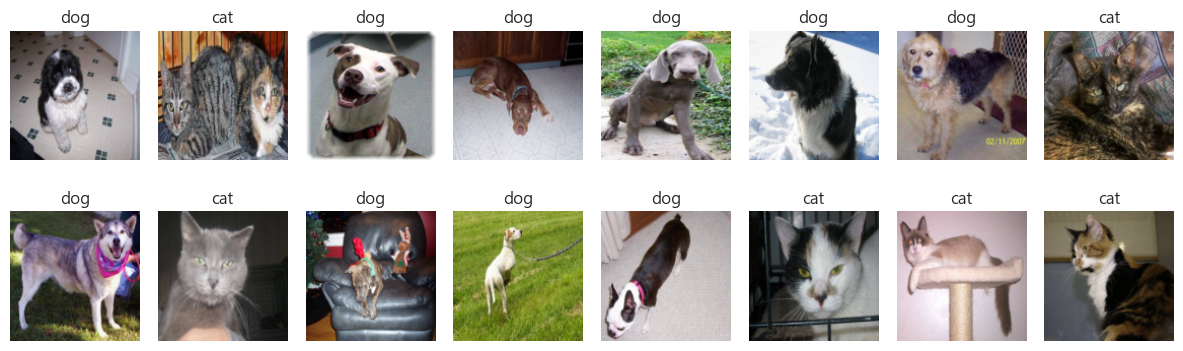

In [60]:
# 시각화
plt.figure(figsize=(12, 4))
for i in range(16): # 32개 중 반만표현
    plt.subplot(2, 8, i+1)

    img = images[i].permute(1, 2, 0) # 컬러채널이기 때문에 matplotlib 표현시 순서 변경
    plt.imshow(img)
    plt.title(f'{class_names[labels[i].item()]}')
    plt.axis('off') # 그래프 줄지우기 

plt.tight_layout()
plt.show()

#### CNN모델정의

In [61]:
# 사용모듈 로드
import torch
import torch.nn as nn
import torch.nn.functional as F

In [65]:
# 클래스 정의
class CatDogCNN(nn.Module):
    def __init__(self):
        super(CatDogCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2) # conv1, conv2 모두 사용
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 32 * 32, 128) # MaxPool(128) -> MaxPool(64) -> 32x32 
        self.fc2 = nn.Linear(128, 1) # 마지막 분류가 0, 1

    def forward(self ,x):
        # conv -> activation -> maxpooling 2회실시
        # dense1, 2통과
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 32 *32)     # flattern -> 1차원 배열화 65,536개 입력
        x = F.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))      # F.sigmoid()는 deprecated
        return x

#### 훈련

In [66]:
# CUDA 준비
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CatDogCNN().to(device)
criterion  = nn.BCELoss()   # Binary Cross Enteropy 손실함수
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [69]:
# 훈련함수
def train(model, loader, criterion, optimizer):
    model.train() # 훈련모드
    total_loss =0
    for images, labels in loader:
        images, labels  = images.to(device), labels.to(device).float().unsqueeze(1) # 1,0 -> [1,], [0,]
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)


In [71]:
# 훈련
EPOCH = 10
for epoch in range(EPOCH):
    loss = train(model, train_loader, criterion, optimizer)
    print(f'[{epoch+1}/ {EPOCH}] Loss: {loss: .4f}')

[1/ 10] Loss:  0.4437
[2/ 10] Loss:  0.3360
[3/ 10] Loss:  0.2387
[4/ 10] Loss:  0.1392
[5/ 10] Loss:  0.0669
[6/ 10] Loss:  0.0303
[7/ 10] Loss:  0.0182
[8/ 10] Loss:  0.0417
[9/ 10] Loss:  0.0250
[10/ 10] Loss:  0.0056


#### 예측결과 시각화

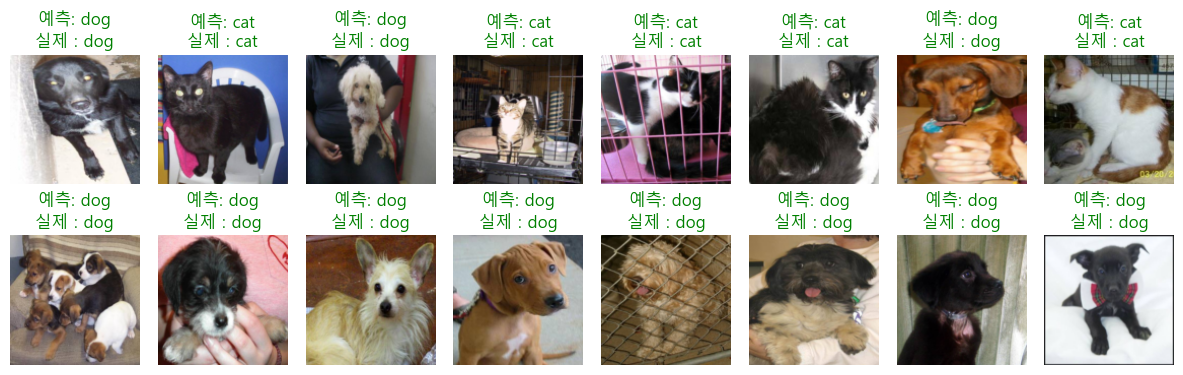

In [75]:
# 검증
model.eval()
images, labels = next(iter(train_loader))
images = images.to(device)
with torch.no_grad():
    outputs = model(images)
    preds = (outputs > 0.5).int(). cpu().squeeze()
plt.figure(figsize=(12, 4))
for i in range(16):
    plt.subplot(2, 8, i+1) 
    plt.imshow(images[i].cpu().permute(1, 2, 0))
    pred_label = 'dog' if preds[i] == 1 else 'cat'
    true_label = 'dog' if labels[i] == 1 else 'cat'
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f'예측: {pred_label}\n실제 : {true_label}', color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()


#### 모델저장 / 불러오기 

In [ ]:
# 가중치만 저장
torch.save(model.state_dict(), './catdog_weight.pth')

In [77]:
# 모델전체 저장
torch.save(model, './catdog_model.pth')

In [80]:
# 가중치만 불러올때 

model2 = CatDogCNN().to(device)
model2.load_state_dict(torch.load('./catdog_weight.pth', map_location=device))
model2

CatDogCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

#### 테스트 이미지로 테스트
- 1.jpg ~ 12500.jpg 까지 Dog,Cat 구분

In [81]:
# 필요모듈 로드
import torch
from torchvision import transforms
from PIL import Image

In [92]:
# trainsform 위 선언
img = Image.open('./data/test/102.jpg').convert('RGB')
img_tensor = transform(img).unsqueeze(0) # [3, 128, 128] - > [1, 3, 128, 128] 4차원 텐서로 변경
# print(img_tensor)
img.show() # 기본 이미지 뷰 프로그램으로 표현

In [93]:
model

CatDogCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=65536, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)

In [94]:
model.eval() #예측, 평가 모드로

with torch.no_grad():
    output = model(img_tensor.to(device))
    pred = (output > 0.5).int().item()

'Dog' if pred == 1 else 'Cat'

'Dog'

#### 폴더로 여러개 테스트

In [97]:
#파이썬 모듈로드
import os, shutil, random

In [98]:
test_dir = './data/test'
images_files = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png'))]

In [96]:
len(images_files)

12500

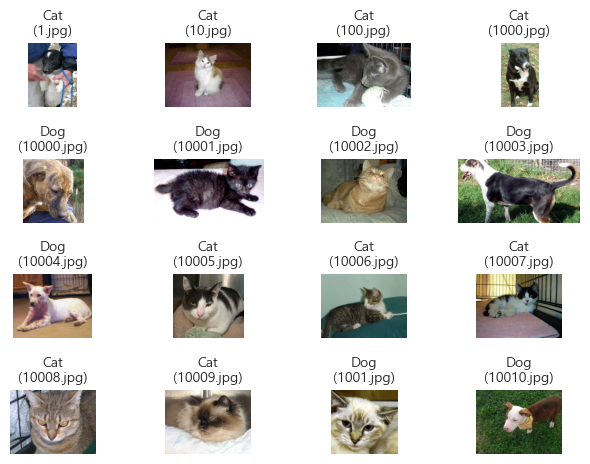

In [100]:
# 예측과 시각화 동시
plt.Figure(figsize=(12, 12))
for i, fname in enumerate(images_files[0:16]): # 최대 16장까지 출력 0:16, 16:32, 32: 48
    img_path = os.path.join(test_dir, fname)
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        pred = 'Dog' if output.item() > 0.5 else 'Cat'

    # 이미지 출력
    plt.subplot(4, 4, i+1)
    plt.imshow(img)
    plt.title(f'{pred}\n({fname})', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Kaggle Competitions 도전
- 캐글상에선 경로 등이 윈도우와 다르기 때문에 설정 변경이 필요

#### 캐글 순서
1. Data > Join the Competitions 클릭
2. Code > New Notbook 클릭(코랩과 동일)
3. 노트북 작성
4. 캐글 서버내 압축파일 처리부분 만 새로 코딩
5. 위의 소스 그대로 사용가능
6. submission.csv 만드는 코드 추가
7. submission.csv 제출

#### 캐글 GPU
- 캐글 노트북 Settiongs > Accelerator > GPU T4 x2, GPU p1000으로 GPU사용가능 (1주 30시간 제한)